In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")

✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1


In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Original preprocessed dataset (should be in Google Drive)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
split_base = "/content/EuroSAT_full_split"
train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")

# Optional: clean old split
if os.path.exists(split_base):
    shutil.rmtree(split_base)

# Create folders
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# List of classes
classes = sorted(os.listdir(source_dir))

# Split and copy
for cls in tqdm(classes, desc="Splitting Classes"):
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))

print("✅ Done! Folders ready at:", split_base)


Splitting Classes: 100%|██████████| 10/10 [10:03<00:00, 60.33s/it]

✅ Done! Folders ready at: /content/EuroSAT_full_split


Found 21721 images belonging to 10 classes.
Found 5432 images belonging to 10 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1387 - loss: 2.2915

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.24043, saving model to best_mobilenetv3.h5


679/679 ━━━━━━━━━━━━━━━━━━━━ 1308s 2s/step - accuracy: 0.1388 - loss: 2.2914 - val_accuracy: 0.2404 - val_loss: 2.0478
Epoch 2/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2383 - loss: 2.0429
Epoch 2: val_accuracy did not improve from 0.24043
679/679 ━━━━━━━━━━━━━━━━━━━━ 1267s 2s/step - accuracy: 0.2383 - loss: 2.0429 - val_accuracy: 0.2285 - val_loss: 1.9712
Epoch 3/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2578 - loss: 1.9535
Epoch 3: val_accuracy improved from 0.24043 to 0.26583, saving model to best_mobilenetv3.h5


679/679 ━━━━━━━━━━━━━━━━━━━━ 1269s 2s/step - accuracy: 0.2578 - loss: 1.9535 - val_accuracy: 0.2658 - val_loss: 1.8738


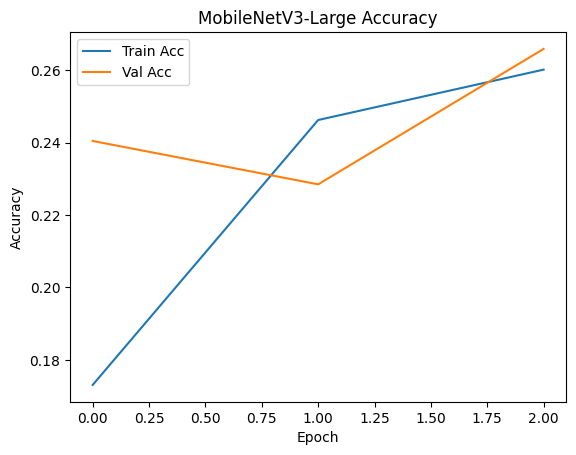

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# ✅ Step 1: Image size and batch size
img_size = (224, 224)  # MobileNetV3 uses 224x224
batch_size = 32

# ✅ Step 2: Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/EuroSAT_full_split/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "/content/EuroSAT_full_split/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# ✅ Step 3: Load MobileNetV3-Large
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze initial layers

# ✅ Step 4: Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ✅ Step 5: Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ✅ Step 6: Callbacks
checkpoint = ModelCheckpoint("best_mobilenetv3.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

# ✅ Step 7: Train (4 epochs)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=[checkpoint, early_stop]
)

# ✅ Step 8: Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV3-Large Accuracy")
plt.legend()
plt.show()


In [8]:
model.save("best_mobilenetv3.keras")  # ✅ This saves in proper format


In [9]:
from tensorflow.keras.models import load_model
model = load_model("best_mobilenetv3.keras")


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Found 5432 images belonging to 10 classes.
170/170 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step


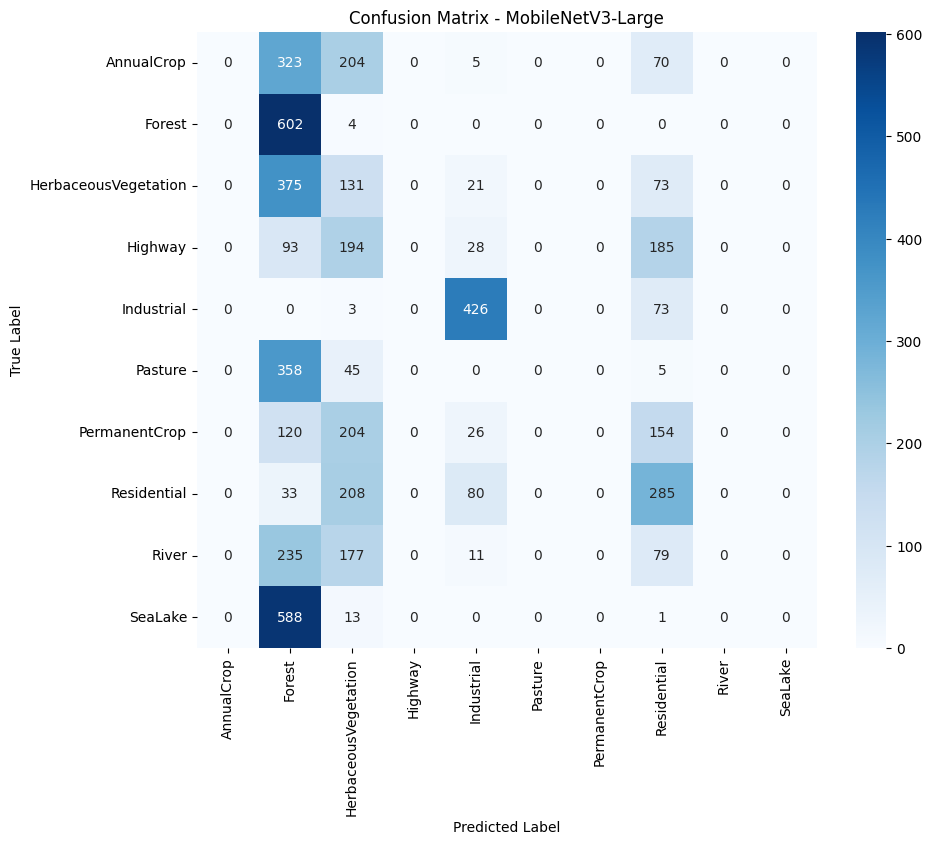

📊 Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.00      0.00      0.00       602
              Forest       0.22      0.99      0.36       606
HerbaceousVegetation       0.11      0.22      0.15       600
             Highway       0.00      0.00      0.00       500
          Industrial       0.71      0.85      0.78       502
             Pasture       0.00      0.00      0.00       408
       PermanentCrop       0.00      0.00      0.00       504
         Residential       0.31      0.47      0.37       606
               River       0.00      0.00      0.00       502
             SeaLake       0.00      0.00      0.00       602

            accuracy                           0.27      5432
           macro avg       0.14      0.25      0.17      5432
        weighted avg       0.14      0.27      0.17      5432



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ✅ Load saved MobileNetV3 model in correct format
model = load_model("best_mobilenetv3.keras")

# ✅ Recreate validation generator
img_size = (224, 224)
batch_size = 32

val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    "/content/EuroSAT_full_split/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ✅ Get predictions
pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# ✅ Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MobileNetV3-Large')
plt.show()

# ✅ Classification report
print("📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [11]:
# Unfreeze some deeper layers
base_model.trainable = True

# Optional: freeze first N layers
for layer in base_model.layers[:-30]:  # freeze all but last 30 layers
    layer.trainable = False


In [12]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2601 - loss: 1.9143
Epoch 1: val_accuracy improved from 0.26583 to 0.30265, saving model to best_mobilenetv3.h5


679/679 ━━━━━━━━━━━━━━━━━━━━ 1287s 2s/step - accuracy: 0.2601 - loss: 1.9143 - val_accuracy: 0.3027 - val_loss: 1.8493
Epoch 2/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2707 - loss: 1.8921
Epoch 2: val_accuracy did not improve from 0.30265
679/679 ━━━━━━━━━━━━━━━━━━━━ 1273s 2s/step - accuracy: 0.2707 - loss: 1.8920 - val_accuracy: 0.2853 - val_loss: 1.8188
Epoch 3/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2771 - loss: 1.8688
Epoch 3: val_accuracy improved from 0.30265 to 0.32235, saving model to best_mobilenetv3.h5


679/679 ━━━━━━━━━━━━━━━━━━━━ 1277s 2s/step - accuracy: 0.2771 - loss: 1.8688 - val_accuracy: 0.3223 - val_loss: 1.8000
Epoch 4/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2890 - loss: 1.8579
Epoch 4: val_accuracy did not improve from 0.32235
679/679 ━━━━━━━━━━━━━━━━━━━━ 1337s 2s/step - accuracy: 0.2890 - loss: 1.8579 - val_accuracy: 0.2758 - val_loss: 1.8397
Epoch 5/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2852 - loss: 1.8598
Epoch 5: val_accuracy did not improve from 0.32235
679/679 ━━━━━━━━━━━━━━━━━━━━ 1253s 2s/step - accuracy: 0.2852 - loss: 1.8598 - val_accuracy: 0.2914 - val_loss: 1.7821


170/170 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step


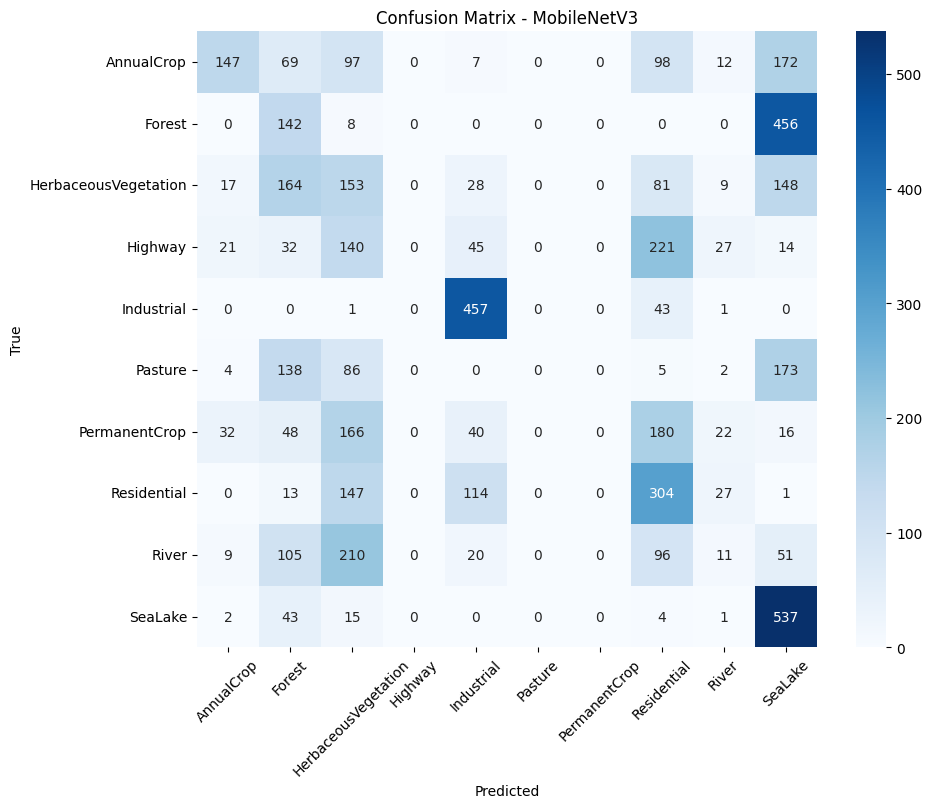

In [13]:
# Get predictions
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MobileNetV3')
plt.xticks(rotation=45)
plt.show()
